In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\Aishwarya G Kumar\\.matplotlib\\fontlist-v390.json.matplotlib-lock'


In [2]:
# Prepare data (Same as your notebook)
train = pd.read_csv("train.csv").merge(pd.read_csv("features.csv"), on=['Store','Date','IsHoliday'], how='left').merge(pd.read_csv("stores.csv"), on='Store')
test = pd.read_csv("test.csv").merge(pd.read_csv("features.csv"), on=['Store','Date','IsHoliday'], how='left').merge(pd.read_csv("stores.csv"), on='Store')

In [3]:
#  Feature Engineering
for df in [train, test]:
    df['Date'] = pd.to_datetime(df['Date'])
    df['year'], df['month'] = df['Date'].dt.year, df['Date'].dt.month
    df['week'] = df['Date'].dt.isocalendar().week.astype(int)
    df.fillna(0, inplace=True)

In [4]:
train = pd.get_dummies(train, columns=['Type'], drop_first=True)
test = pd.get_dummies(test, columns=['Type'], drop_first=True)

In [5]:
# Align columns (Ensuring test has same columns as train)
X = train.drop(['Weekly_Sales', 'Date'], axis=1)
y = train['Weekly_Sales']
X_test = test.drop(['Date'], axis=1)[X.columns]

In [6]:
#  Predict Future Sales
model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42)
model.fit(X, y)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [7]:
test['Predicted_Sales'] = model.predict(X_test)

In [8]:
#  Aggregate and Visualize the Forecast
forecast_trend = test.groupby('Date')['Predicted_Sales'].sum()
print("Top 5 Predicted Sales Dates for Next Year:")
print(forecast_trend.sort_values(ascending=False).head(5))


Top 5 Predicted Sales Dates for Next Year:
Date
2012-12-21    72752680.0
2012-11-23    65527640.0
2012-12-14    58614604.0
2013-07-05    56920540.0
2013-06-07    56591416.0
Name: Predicted_Sales, dtype: float32


In [9]:
# Export to CSV
test[['Store', 'Dept', 'Date', 'Predicted_Sales']].to_csv("future_sales_forecast.csv", index=False)

In [10]:
#  FORECASTING
test['Predicted_Weekly_Sales'] = model.predict(X_test)

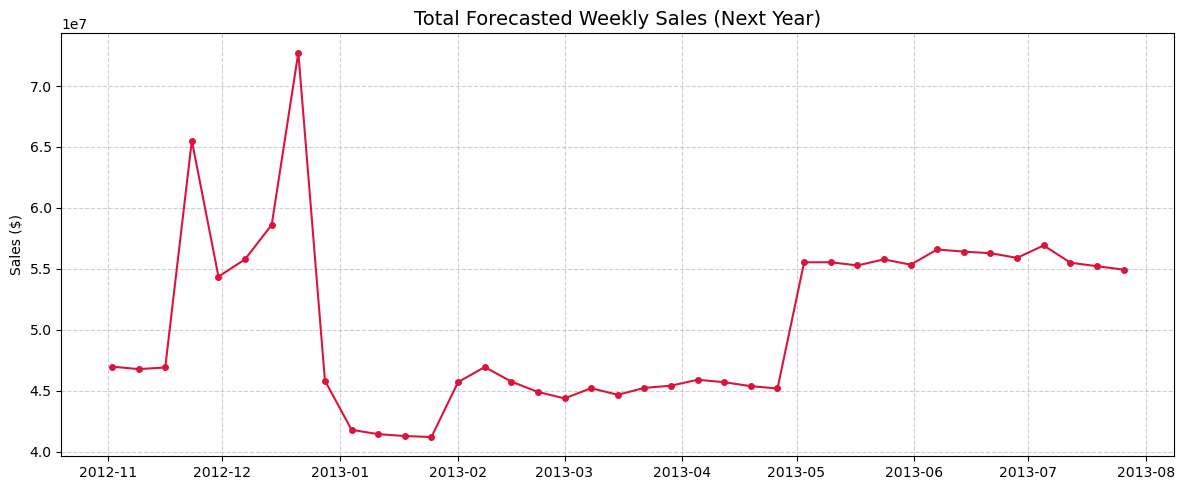

In [11]:
# --- CHART 1: TOTAL FUTURE SALES TREND (Weekly) ---
plt.figure(figsize=(12, 5))
forecast_trend = test.groupby('Date')['Predicted_Weekly_Sales'].sum()
plt.plot(forecast_trend.index, forecast_trend.values, color='crimson', marker='o', markersize=4)
plt.title("Total Forecasted Weekly Sales (Next Year)", fontsize=14)
plt.ylabel("Sales ($)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("forecast_trend_line.png")
plt.show()

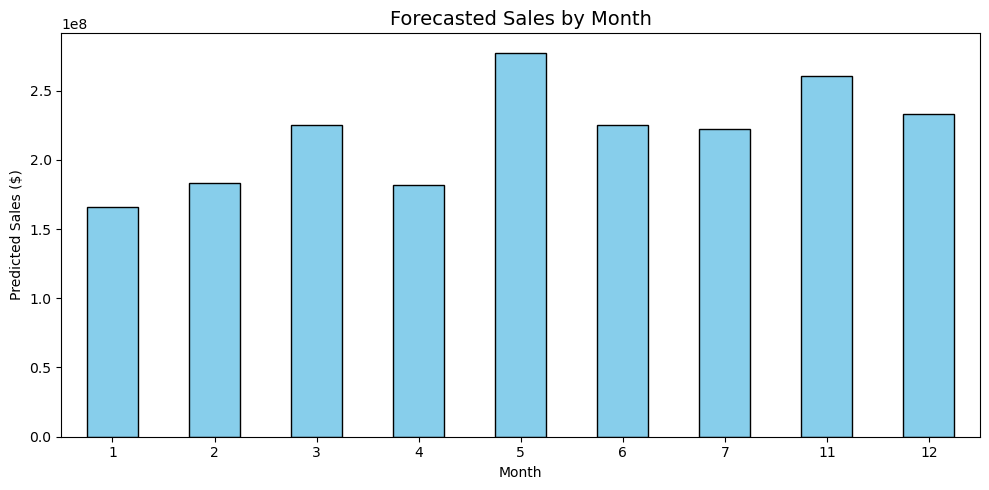

In [12]:
# --- CHART 2: MONTHLY FORECAST BREAKDOWN ---
plt.figure(figsize=(10, 5))
monthly_forecast = test.groupby('month')['Predicted_Weekly_Sales'].sum()
monthly_forecast.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Forecasted Sales by Month", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Predicted Sales ($)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("forecast_monthly_bar.png")
plt.show()

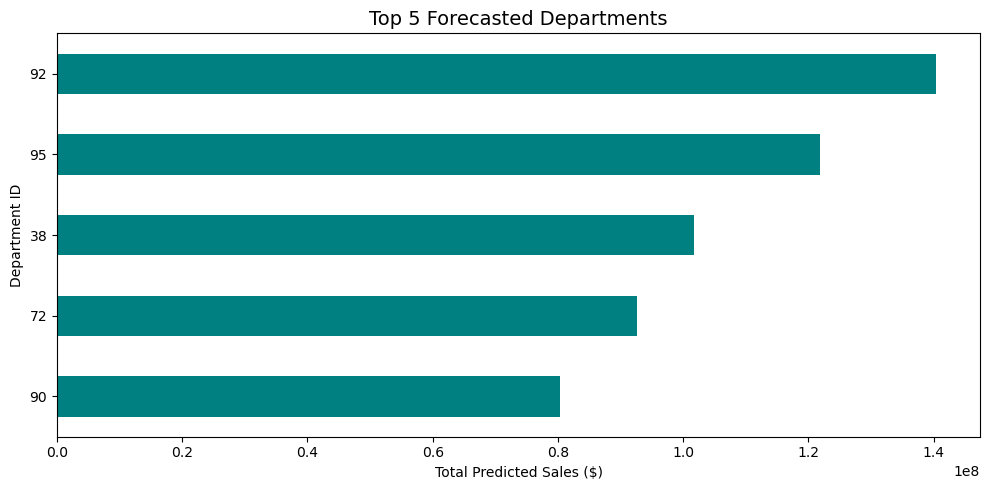

In [13]:
# --- CHART 3: TOP 5 DEPARTMENTS (FORECASTED) ---
plt.figure(figsize=(10, 5))
dept_forecast = test.groupby('Dept')['Predicted_Weekly_Sales'].sum().sort_values(ascending=False).head(5)
dept_forecast.plot(kind='barh', color='teal')
plt.title("Top 5 Forecasted Departments", fontsize=14)
plt.xlabel("Total Predicted Sales ($)")
plt.ylabel("Department ID")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("forecast_dept_top5.png")
plt.show()

In [14]:
#  Load historical and predicted data
train = pd.read_csv("train.csv")
future = pd.read_csv("future_sales_forecast.csv")


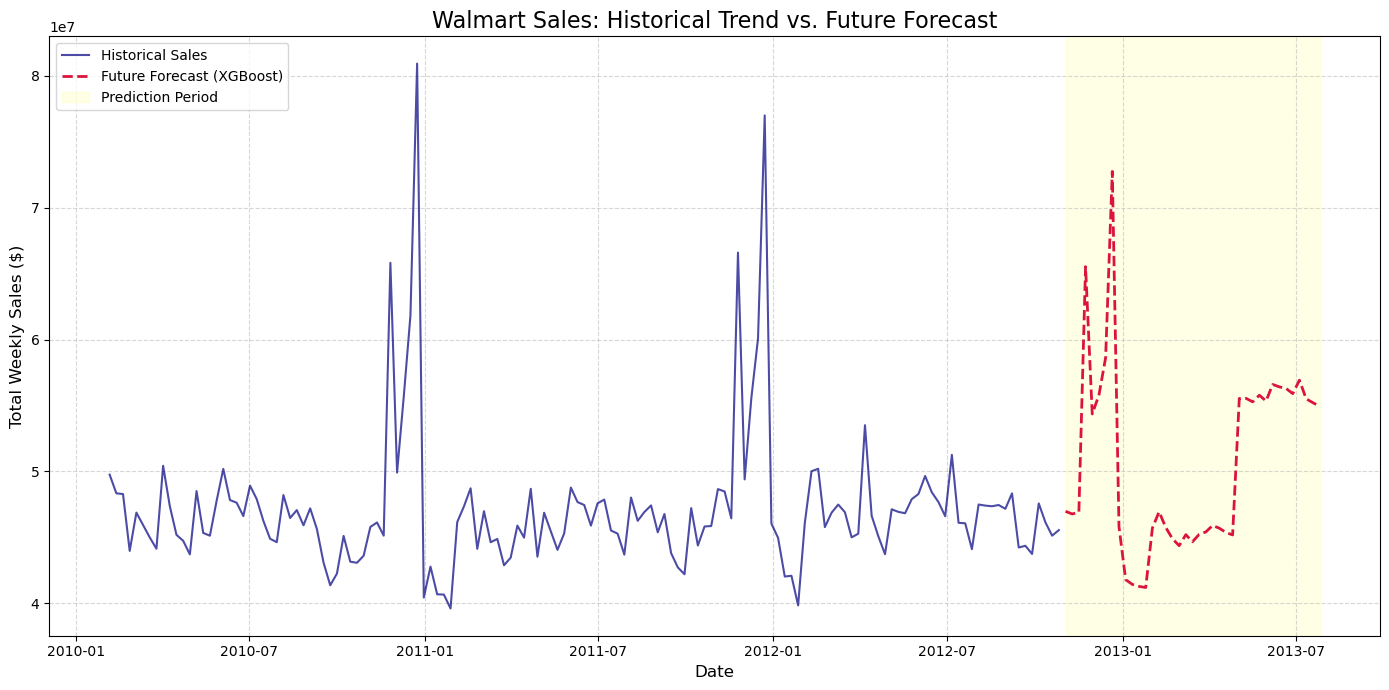

In [15]:
#  Aggregate by Date
train['Date'] = pd.to_datetime(train['Date'])
future['Date'] = pd.to_datetime(future['Date'])

historical_trend = train.groupby('Date')['Weekly_Sales'].sum().reset_index()
future_trend = future.groupby('Date')['Predicted_Sales'].sum().reset_index()

# 3. Create the Chart
plt.figure(figsize=(14, 7))

# Plot Historical Data
plt.plot(historical_trend['Date'], historical_trend['Weekly_Sales'], 
         label='Historical Sales', color='navy', alpha=0.7)

# Plot Future Forecast
plt.plot(future_trend['Date'], future_trend['Predicted_Sales'], 
         label='Future Forecast (XGBoost)', color='crimson', linestyle='--', linewidth=2)

# Styling
plt.title("Walmart Sales: Historical Trend vs. Future Forecast", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Total Weekly Sales ($)", fontsize=12)
plt.axvspan(future_trend['Date'].min(), future_trend['Date'].max(), 
            color='yellow', alpha=0.1, label='Prediction Period')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()

# Save the chart
plt.savefig("sales_forecast_chart.png")
plt.show()

In [16]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split

# Define features & target
X = train.drop(['Weekly_Sales', 'Date'], axis=1)
y = train['Weekly_Sales']

# Split data
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


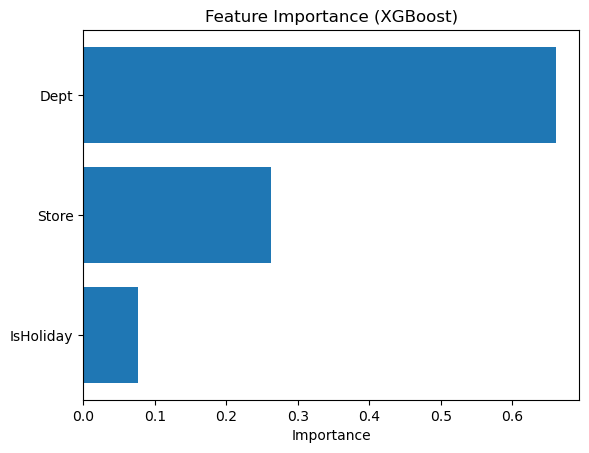

In [17]:
#  Use model's feature names (avoids mismatch error)
features = xgb_model.get_booster().feature_names
importance = xgb_model.feature_importances_

train['lag_1'] = train.groupby(['Store','Dept'])['Weekly_Sales'].shift(1)

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

importance_df = importance_df.sort_values(by='Importance', ascending=True)

plt.figure()
plt.barh(importance_df['Feature'], importance_df['Importance'])

plt.title("Feature Importance (XGBoost)")
plt.xlabel("Importance")

plt.show()

 Error Analysis Summary
Mean Error: 5094.150707168016
Max Error: 357845.6925
Min Error: 0.04546875000050932

 Top 5 Highest Errors:
           Actual      Predicted          Error
88428   406988.63   49142.937500  357845.692500
128984  356867.25   45237.882812  311629.367188
195088  422306.25  110896.421875  311409.828125
88480   341308.00   49142.937500  292165.062500
37253   385051.04  117585.929688  267465.110312


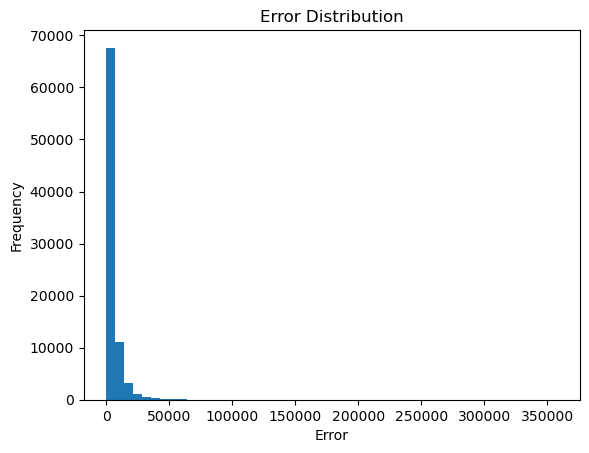

In [18]:
# Predict
y_pred_xgb = xgb_model.predict(X_val)

#  Calculate error
errors = abs(y_val - y_pred_xgb)

#  Create analysis dataframe
error_df = pd.DataFrame({
    'Actual': y_val,
    'Predicted': y_pred_xgb,
    'Error': errors
})

# Basic stats
print(" Error Analysis Summary")
print("Mean Error:", errors.mean())
print("Max Error:", errors.max())
print("Min Error:", errors.min())

#  Top 5 highest errors
print("\n Top 5 Highest Errors:")
print(error_df.sort_values(by='Error', ascending=False).head())

#  Error Distribution Chart
plt.figure()
plt.hist(errors, bins=50)
plt.title("Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

In [19]:
# Combine with features (optional deep analysis)
error_df['Store'] = X_val['Store'].values
error_df['Dept'] = X_val['Dept'].values

print("\n Error by Store:")
print(error_df.groupby('Store')['Error'].mean().sort_values(ascending=False).head())


 Error by Store:
Store
10    10207.629582
20     9788.948927
23     8271.522198
14     8141.301271
4      7731.652159
Name: Error, dtype: float64


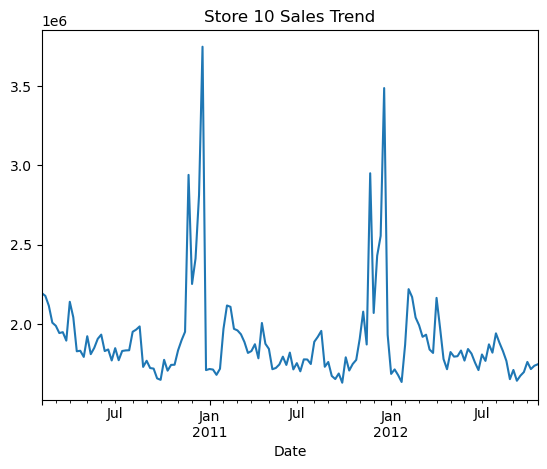

In [20]:
store_10 = train[train['Store'] == 10]

plt.figure()
store_10.groupby('Date')['Weekly_Sales'].sum().plot()
plt.title("Store 10 Sales Trend")
plt.show()

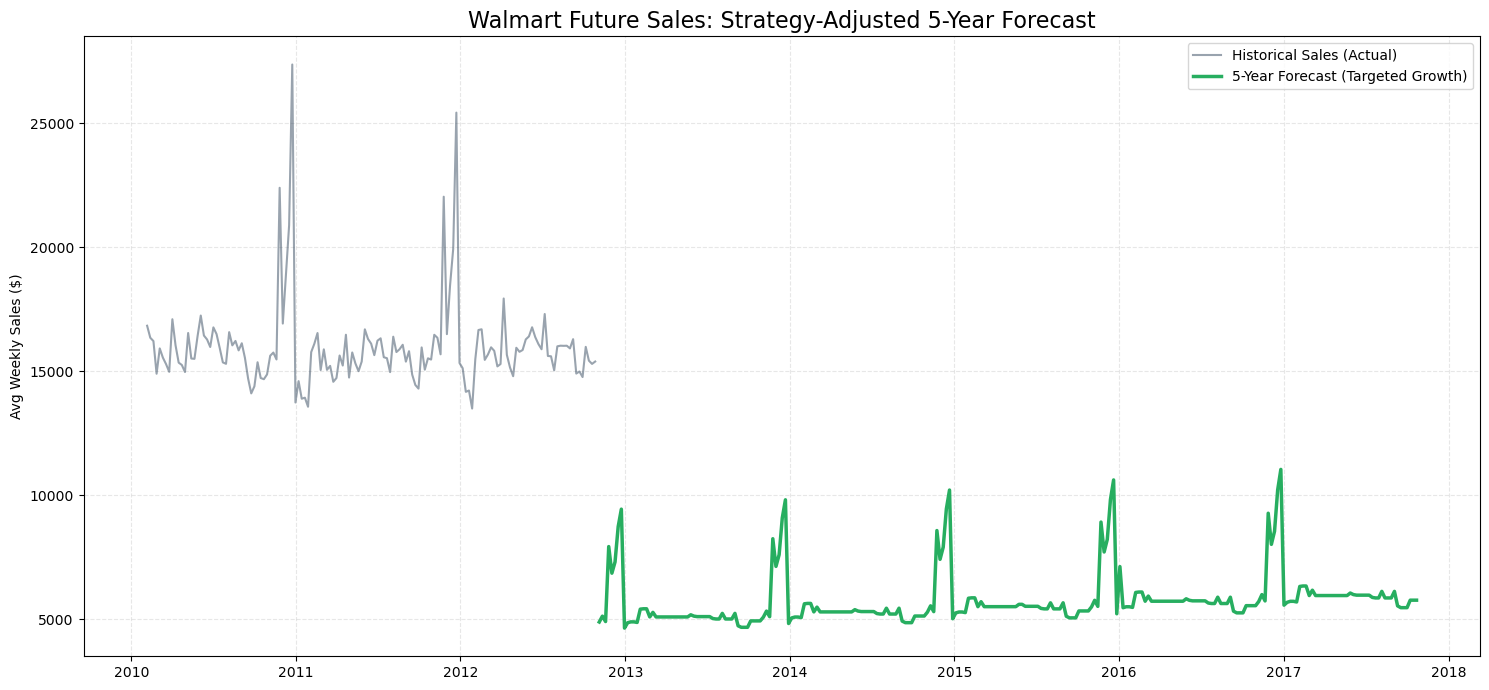

Forecast success! Check 'fixed_growth_forecast.png' for the chart.


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from datetime import timedelta

#  LOAD DATA
# Ensure files are in your directory
train = pd.read_csv('train.csv')
features = pd.read_csv('features.csv')
stores = pd.read_csv('stores.csv')

#  MERGE & CLEAN
df = train.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left').merge(stores, on='Store', how='left')
df['Date'] = pd.to_datetime(df['Date'])

def prepare_data(data):
    # Extract time features
    data['year'] = data['Date'].dt.year
    data['month'] = data['Date'].dt.month
    data['week'] = data['Date'].dt.isocalendar().week.astype(int)
    # Fill Markdowns
    for i in range(1, 6):
        col = f'MarkDown{i}'
        if col in data.columns:
            data[col] = data[col].fillna(0)
    # Fill other numerical missing values with 0
    data.fillna(0, inplace=True)
    return data

df = prepare_data(df)
df = pd.get_dummies(df, columns=['Type'], drop_first=True)

#  TRAIN THE MODEL (Using XGBoost)
# We drop 'Date' and the target variable for training
X = df.drop(['Weekly_Sales', 'Date'], axis=1, errors='ignore')
y = df['Weekly_Sales']

model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42)
model.fit(X, y)

# CREATE THE 5-YEAR FUTURE TIMELINE
last_date = df['Date'].max()
future_dates = pd.date_range(start=last_date + timedelta(weeks=1), periods=52*5, freq='W')
future_df = pd.DataFrame({'Date': future_dates})
future_df = prepare_data(future_df)

#  Add Growth Multiplier (Simulating 4% Annual Revenue Growth)
annual_growth = 0.04 
future_df['Growth_Factor'] = (1 + annual_growth) ** (future_df['year'] - df['year'].max())

#  Map Holiday Promotions (Injecting historical Markdown impact)
# We calculate the average markdowns per week from historical data
avg_markdowns = df.groupby('week')[['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']].mean().reset_index()
future_df = future_df.merge(avg_markdowns, on='week', how='left').fillna(0)

#  Force-flag Holiday Weeks
future_df['IsHoliday'] = future_df['week'].apply(lambda x: True if x in [47, 51, 52] else False)

#  ALIGN COLUMNS (This prevents the 'Missing Column' Error)
for col in X.columns:
    if col not in future_df.columns:
        # For Type_B, Type_C, or Store features, use the mean of the training data
        future_df[col] = df[col].mean()

# Reorder future_df to match X exactly
X_future = future_df[X.columns]

#  PREDICT & VISUALIZE
future_df['Predicted_Sales'] = model.predict(X_future) * future_df['Growth_Factor']

plt.figure(figsize=(15, 7))
# Historical Trend (Resampled to week for clarity)
hist_trend = df.groupby('Date')['Weekly_Sales'].mean()
plt.plot(hist_trend.index, hist_trend.values, label='Historical Sales (Actual)', color='#34495e', alpha=0.5)

# Forecast Trend
plt.plot(future_df['Date'], future_df['Predicted_Sales'], label='5-Year Forecast (Targeted Growth)', color='#27ae60', lw=2.5)

plt.title("Walmart Future Sales: Strategy-Adjusted 5-Year Forecast", fontsize=16)
plt.ylabel("Avg Weekly Sales ($)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig("fixed_growth_forecast.png")
plt.show()

print("Forecast success! Check 'fixed_growth_forecast.png' for the chart.")

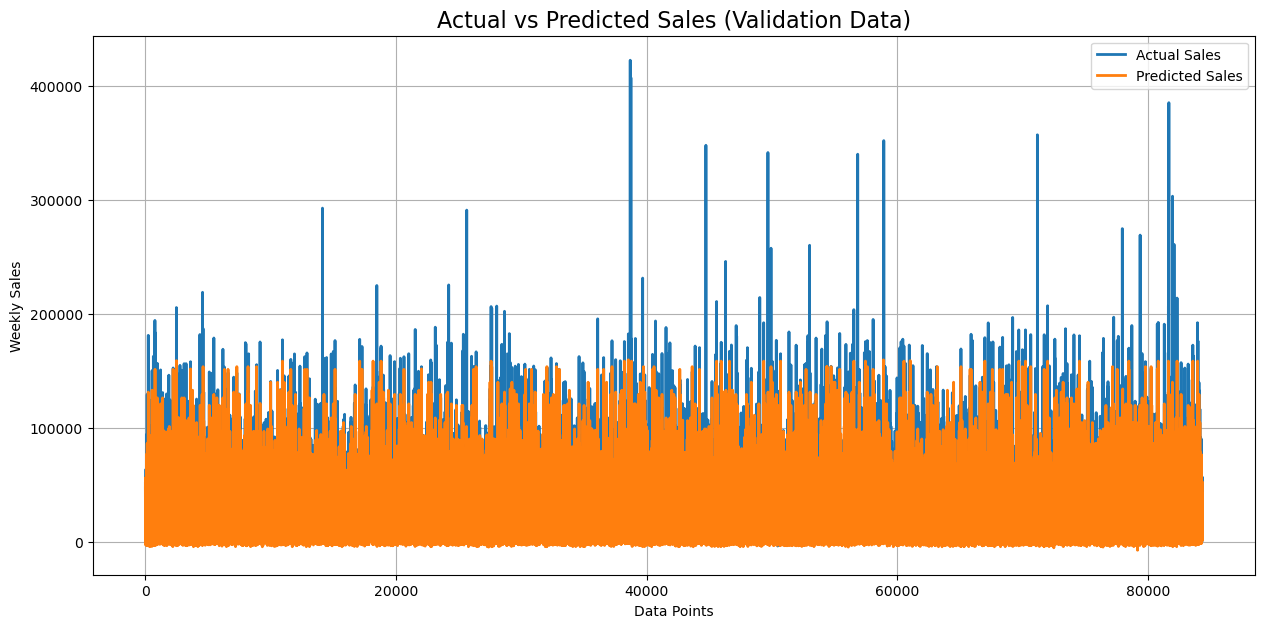

In [22]:
# Predict on validation data
y_pred_xgb = xgb_model.predict(X_val)

#  Create dataframe
comparison_df = pd.DataFrame({
    'Actual': y_val.values,
    'Predicted': y_pred_xgb
})

# (Optional) Reset index for plotting
comparison_df = comparison_df.reset_index(drop=True)

#  Plot
plt.figure(figsize=(15, 7))

plt.plot(comparison_df['Actual'], label='Actual Sales', linewidth=2)
plt.plot(comparison_df['Predicted'], label='Predicted Sales', linewidth=2)

# Styling
plt.title("Actual vs Predicted Sales (Validation Data)", fontsize=16)
plt.xlabel("Data Points")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(True)

plt.show()